In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import re,sys,os
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

# Optional: Set PDF to embed fonts (for Illustrator editing)
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for better editing

In [3]:
input_dir = Path(r"F:\lab\cptac_prostate\data\mspycloud\Global DDA")
data_path = input_dir / "protein_matrix-log2_ratios-MD_norm.tsv"
out_dir = Path(r"E:\lab\cptac-prostate\20260401_quality_control")

In [4]:
data = pd.read_csv(data_path, sep="\t")
data

,Protein.Group.Accessions,Reference Sample 1,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 6,Sample 7,Sample 8,...,Sample 195,Sample 196,Sample 197,Sample 198,Sample 199,Sample 200,Sample 201,Sample 202,Sample 203,Sample 204
0,Cont|ENSEMBL:ENSBTAP00000006074 (Bos taurus) 8...,0.0,-1.130748,-0.120022,-0.823255,-0.202982,-0.909153,-0.356942,2.013271,-0.194490,...,0.611663,0.614156,0.313223,-0.361448,-0.285143,1.151174,-0.099341,0.159085,-0.214928,0.083377
1,Cont|ENSEMBL:ENSBTAP00000016046 (Bos taurus) s...,0.0,-0.973916,-0.020931,0.331719,-0.052797,-0.511451,0.181322,0.425169,0.539178,...,0.368382,0.752786,-0.818105,-0.760564,-0.489010,-1.610888,-0.084720,0.229588,-0.471814,-0.822965
2,Cont|ENSEMBL:ENSBTAP00000025008 (Bos taurus) h...,0.0,0.067903,0.190226,0.455358,0.502275,-0.064744,0.093300,0.610616,0.017623,...,-1.052417,-0.902148,0.075325,-0.059005,-1.475443,-0.178476,-0.188606,-0.741257,-0.809814,-0.284416
3,Cont|ENSEMBL:ENSBTAP00000031900 (Bos taurus) 1...,0.0,-0.935545,0.837979,0.194083,0.070462,-0.218718,0.492282,-0.699660,0.952075,...,0.446675,0.569019,0.289291,-0.411408,-0.379671,-0.731231,0.946198,-0.472550,-0.240163,-0.888980
4,Cont|H-INV:HIT000292931 Tax_Id=9606 Gene_Symbo...,0.0,0.129429,0.026374,0.389043,-0.348435,0.298547,-0.010228,-0.303386,0.053259,...,0.073109,0.086894,-0.436049,0.129537,0.283453,-0.014933,-0.231216,0.026891,0.165215,0.801281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9781,ENSP00000307014|ENST00000305748|ENSG0000018604...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.704660,1.032442,-0.274949,-0.304587,0.167760,-0.271454,0.214391,0.833111,0.328482,0.000546
9782,ENSP00000312070|ENST00000308177|ENSG0000024018...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.015504,0.175960,0.339498,0.119853,0.172466,-0.107425,0.501688,0.064922,0.034634,-0.415016
9783,ENSP00000452370|ENST00000557607|ENSG0000010072...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.491171,0.539038,-0.074879,-0.652432,-0.224975,0.030425,0.281268,-0.544750,0.020144,0.259134
9784,ENSP00000453717|ENST00000558813|ENSG0000012895...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.301151,1.170550,-0.481406,-0.018623,0.255800,-0.449918,0.233614,0.309210,-0.115756,-0.228818


In [5]:
meta_dir = Path(r"F:\lab\cptac_prostate\data\mspycloud\Sample ID match")
sample_path = meta_dir / "PRAD_TMT_DDA_CPTAC Sample ID match.xlsx"
sample_path.exists()


True

In [6]:

sample_df = pd.read_excel(sample_path)
sample_df

,sample number,sample ID,channel,TMT/DIA set,sample type
0,Referance Sample 1,pool_1,126,1,pool
1,Sample 1,C3L-05292_T,127N,1,tumor
2,Sample 2,C3L-09383_T,127C,1,tumor
3,Sample 3,CHTN-43798_T,128N,1,tumor
4,Sample 4,C3L-06261_N,128C,1,normal
...,...,...,...,...,...
211,Sample 200,C3L-08291_T,133N,12,tumor
212,Sample 201,C3L-10583_T,133C,12,tumor
213,Sample 202,C3L-07877_T,134N,12,tumor
214,Sample 203,C3L-08377_T,134C,12,tumor


In [7]:
sample_map = dict(zip(sample_df["sample number"], sample_df["sample ID"]))

In [8]:
cols = [sample_map.get(i,i) for i in data.columns]
print(len(cols), len(data.columns))

217 217


In [9]:
data.columns = cols

In [10]:
data

,Protein.Group.Accessions,Reference Sample 1,C3L-05292_T,C3L-09383_T,CHTN-43798_T,C3L-06261_N,C3L-08811_T,C3L-06506_N,C3L-07804_T,C3L-06595_T,...,CHTN-44966_T,C3L-11192_N,C3L-08805_T,C3L-09760_T,C3L-08444_T,C3L-08291_T,C3L-10583_T,C3L-07877_T,C3L-08377_T,C3L-08736_T
0,Cont|ENSEMBL:ENSBTAP00000006074 (Bos taurus) 8...,0.0,-1.130748,-0.120022,-0.823255,-0.202982,-0.909153,-0.356942,2.013271,-0.194490,...,0.611663,0.614156,0.313223,-0.361448,-0.285143,1.151174,-0.099341,0.159085,-0.214928,0.083377
1,Cont|ENSEMBL:ENSBTAP00000016046 (Bos taurus) s...,0.0,-0.973916,-0.020931,0.331719,-0.052797,-0.511451,0.181322,0.425169,0.539178,...,0.368382,0.752786,-0.818105,-0.760564,-0.489010,-1.610888,-0.084720,0.229588,-0.471814,-0.822965
2,Cont|ENSEMBL:ENSBTAP00000025008 (Bos taurus) h...,0.0,0.067903,0.190226,0.455358,0.502275,-0.064744,0.093300,0.610616,0.017623,...,-1.052417,-0.902148,0.075325,-0.059005,-1.475443,-0.178476,-0.188606,-0.741257,-0.809814,-0.284416
3,Cont|ENSEMBL:ENSBTAP00000031900 (Bos taurus) 1...,0.0,-0.935545,0.837979,0.194083,0.070462,-0.218718,0.492282,-0.699660,0.952075,...,0.446675,0.569019,0.289291,-0.411408,-0.379671,-0.731231,0.946198,-0.472550,-0.240163,-0.888980
4,Cont|H-INV:HIT000292931 Tax_Id=9606 Gene_Symbo...,0.0,0.129429,0.026374,0.389043,-0.348435,0.298547,-0.010228,-0.303386,0.053259,...,0.073109,0.086894,-0.436049,0.129537,0.283453,-0.014933,-0.231216,0.026891,0.165215,0.801281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9781,ENSP00000307014|ENST00000305748|ENSG0000018604...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.704660,1.032442,-0.274949,-0.304587,0.167760,-0.271454,0.214391,0.833111,0.328482,0.000546
9782,ENSP00000312070|ENST00000308177|ENSG0000024018...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.015504,0.175960,0.339498,0.119853,0.172466,-0.107425,0.501688,0.064922,0.034634,-0.415016
9783,ENSP00000452370|ENST00000557607|ENSG0000010072...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.491171,0.539038,-0.074879,-0.652432,-0.224975,0.030425,0.281268,-0.544750,0.020144,0.259134
9784,ENSP00000453717|ENST00000558813|ENSG0000012895...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.301151,1.170550,-0.481406,-0.018623,0.255800,-0.449918,0.233614,0.309210,-0.115756,-0.228818


In [11]:
data = data[~data['Protein.Group.Accessions'].str.contains("Cont\|")]

In [12]:
data

,Protein.Group.Accessions,Reference Sample 1,C3L-05292_T,C3L-09383_T,CHTN-43798_T,C3L-06261_N,C3L-08811_T,C3L-06506_N,C3L-07804_T,C3L-06595_T,...,CHTN-44966_T,C3L-11192_N,C3L-08805_T,C3L-09760_T,C3L-08444_T,C3L-08291_T,C3L-10583_T,C3L-07877_T,C3L-08377_T,C3L-08736_T
79,ENSP00000000233|ENST00000000233|ENSG0000000405...,0.0,0.077557,-0.188949,-0.138365,-0.257077,0.236871,-0.122824,0.049553,-0.150596,...,0.176787,-0.184523,-0.495843,0.065633,0.050085,0.264361,-0.222978,0.084177,-0.024535,0.268297
80,ENSP00000000412|ENST00000000412|ENSG0000000305...,0.0,0.122930,0.035690,0.178924,0.037180,0.363048,0.022977,-0.226062,-0.218910,...,-0.210869,-0.509647,0.323025,0.113045,-0.003798,-0.363352,-0.292304,0.175106,0.113948,0.243517
81,ENSP00000001008|ENST00000001008|ENSG0000000447...,0.0,-0.158234,-0.186515,-0.186968,-0.404329,0.401197,-0.287155,-0.581152,-0.184295,...,-0.236309,-0.562297,-0.306163,0.162493,0.084923,0.159238,-0.422580,-0.059347,-0.186794,0.221885
82,ENSP00000002125|ENST00000002125|ENSG0000000350...,0.0,-0.006707,0.084774,-0.037492,-0.064694,0.156628,-0.020285,-0.202836,0.050429,...,-0.262661,0.020508,0.195666,0.066539,0.017474,-0.082235,0.026820,-0.052671,-0.023878,0.303552
83,ENSP00000002165|ENST00000002165|ENSG0000000103...,0.0,0.076355,0.294062,0.096679,-0.752725,0.074150,-0.745087,-1.052131,-0.236542,...,0.023394,-0.138491,-0.132877,0.102584,-0.292972,0.625113,-0.612706,-0.504245,0.224542,0.708998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9781,ENSP00000307014|ENST00000305748|ENSG0000018604...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.704660,1.032442,-0.274949,-0.304587,0.167760,-0.271454,0.214391,0.833111,0.328482,0.000546
9782,ENSP00000312070|ENST00000308177|ENSG0000024018...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.015504,0.175960,0.339498,0.119853,0.172466,-0.107425,0.501688,0.064922,0.034634,-0.415016
9783,ENSP00000452370|ENST00000557607|ENSG0000010072...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.491171,0.539038,-0.074879,-0.652432,-0.224975,0.030425,0.281268,-0.544750,0.020144,0.259134
9784,ENSP00000453717|ENST00000558813|ENSG0000012895...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.301151,1.170550,-0.481406,-0.018623,0.255800,-0.449918,0.233614,0.309210,-0.115756,-0.228818


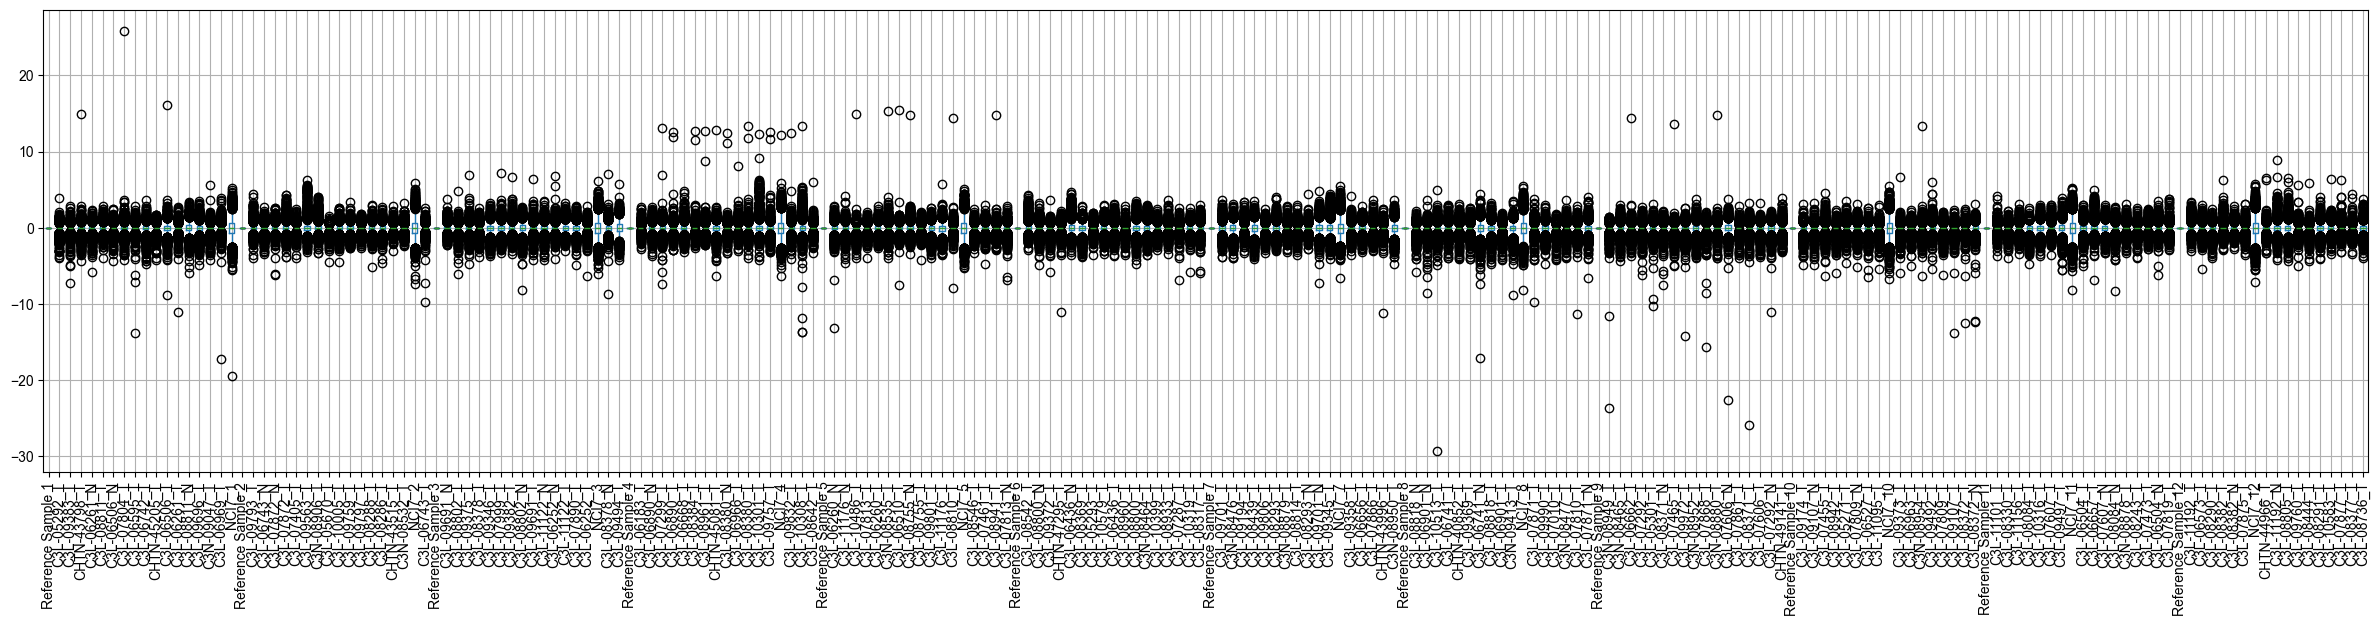

In [13]:
fig = data.boxplot(figsize=(30,6), rot=90)
qc_figure_path = out_dir / "mspycloud_Global_DDA_TMT_QC.png"
plt.savefig(qc_figure_path, dpi=300, bbox_inches='tight')

In [14]:
data = data.set_index("Protein.Group.Accessions")

In [15]:
data.median()

Reference Sample 1    0.000000
C3L-05292_T           0.000540
C3L-09383_T          -0.000956
CHTN-43798_T         -0.000416
C3L-06261_N          -0.001173
                        ...   
C3L-08291_T           0.001527
C3L-10583_T          -0.001369
C3L-07877_T          -0.000367
C3L-08377_T           0.000000
C3L-08736_T           0.001400
Length: 216, dtype: float64

In [16]:
sample_medians = data.median()
global_median = 0
scale_factors = global_median - sample_medians
data_norm = data + scale_factors

In [17]:
data_norm.median()

Reference Sample 1    0.000000e+00
C3L-05292_T           0.000000e+00
C3L-09383_T           0.000000e+00
CHTN-43798_T          0.000000e+00
C3L-06261_N          -1.084202e-19
                          ...     
C3L-08291_T           0.000000e+00
C3L-10583_T           0.000000e+00
C3L-07877_T           0.000000e+00
C3L-08377_T           0.000000e+00
C3L-08736_T           0.000000e+00
Length: 216, dtype: float64

In [19]:
out_table_path = out_dir / "mspycloud_Global_DDA_TMT_Clean_MD.tsv"
data_norm.to_csv(out_table_path, sep="\t",index=True)